In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Veri setini yükleme
df = pd.read_csv('train.csv')

In [3]:
#Veri Setini İnceleme
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


# --- VERİ ÖN İŞLEME ---

In [6]:
# 1. Eksik Veri Analizi
print("Eksik Veri Sayısı:\n", df.isnull().sum().sum())

Eksik Veri Sayısı:
 0


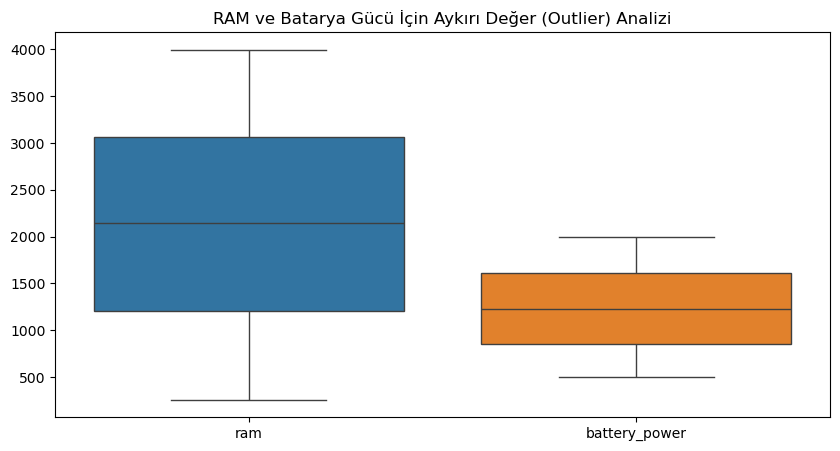

In [7]:
# 2. Aykırı Değer Analizi (RAM ve Batarya Kapasitesi)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['ram', 'battery_power']])
plt.title('RAM ve Batarya Gücü İçin Aykırı Değer (Outlier) Analizi')
plt.show()

In [8]:
# 3. Feature Seçimi (Özellikler ve Hedef Değişkeni Ayırma)
X = df.drop('price_range', axis=1)
y = df['price_range']

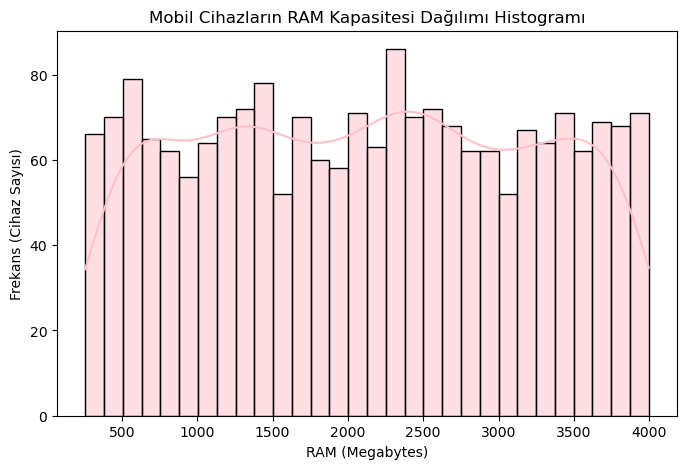

In [9]:
# --- VERİ GÖRSELLEŞTİRME ---

# İstenilen Histogram Grafiği (RAM Dağılımı)
plt.figure(figsize=(8, 5))
sns.histplot(df['ram'], bins=30, kde=True, color='pink')
plt.title('Mobil Cihazların RAM Kapasitesi Dağılımı Histogramı')
plt.xlabel('RAM (Megabytes)')
plt.ylabel('Frekans (Cihaz Sayısı)')
plt.show()

# --- MODEL OLUŞTURMA ---

In [10]:
# 1. Train-test split (%70 Eğitim, %30 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [11]:
# 2. Pipeline (Veri Normalizasyonu / Özellik Ölçekleme ve Model)
# StandartScaler ile verileri ölçekliyoruz (Ödev Adımı 2'deki özellik ölçekleme)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

In [12]:
# 3. Model Kurulumu ve Hiperparametreler (C, gamma, kernel)
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01],
    'svm__kernel': ['linear', 'rbf', 'poly']
}

In [13]:
# 4. GridSearchCV (cv=10)
grid_search = GridSearchCV(estimator=pipeline, 
                           param_grid=param_grid, 
                           cv=10, 
                           n_jobs=-1, 
                           verbose=1)
print("GridSearchCV ile en iyi parametreler aranıyor ve model eğitiliyor...")
grid_search.fit(X_train, y_train)

GridSearchCV ile en iyi parametreler aranıyor ve model eğitiliyor...
Fitting 10 folds for each of 48 candidates, totalling 480 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto', ...], 'svm__kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [14]:
# En iyi parametreleri ekrana yazdırma
print("\nBulunan En İyi Parametreler:")
print(grid_search.best_params_)


Bulunan En İyi Parametreler:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [15]:
# 5. Tahmin
y_pred = grid_search.predict(X_test)

# --- MODEL DEĞERLENDİRME ---

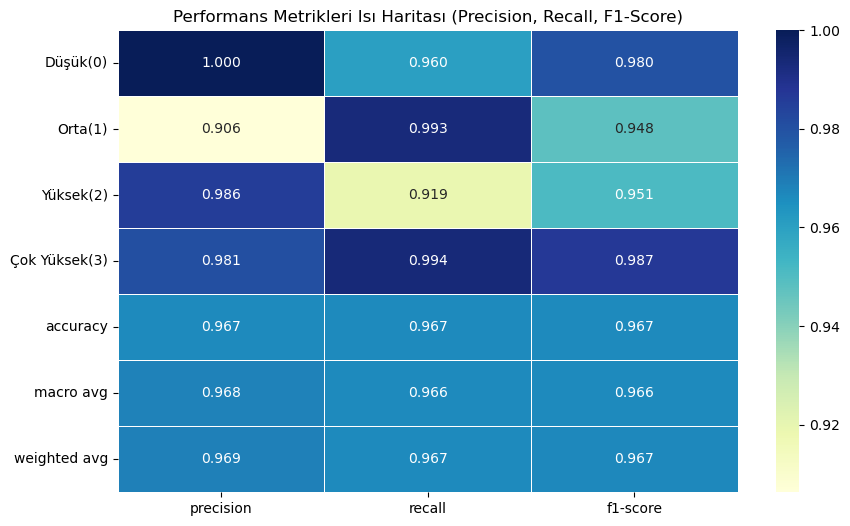

In [18]:
# PERFORMANS METRİKLERİ GÖRSELLEŞTİRMESİ (ISIL HARİTA - HEATMAP)

# classification_report'u bir DataFrame'e dönüştürebilmek için output_dict=True yapıyoruz
report_dict = classification_report(y_test, y_pred, 
                                    target_names=["Düşük(0)", "Orta(1)", "Yüksek(2)", "Çok Yüksek(3)"], 
                                    output_dict=True)

# Sözlüğü Pandas DataFrame'e çeviriyoruz
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

# Performans Metrikleri için Isı Haritası (Heatmap) çizdiriyoruz
plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=.5, cbar=True)
plt.title('Performans Metrikleri Isı Haritası (Precision, Recall, F1-Score)')
plt.show()

<Figure size 800x600 with 0 Axes>

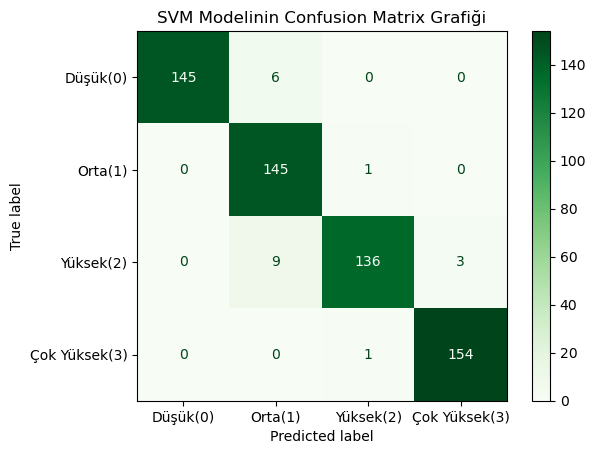

In [17]:
# Confusion Matrix Görselleştirmesi
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Düşük(0)", "Orta(1)", "Yüksek(2)", "Çok Yüksek(3)"])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Greens', values_format='d')
plt.title('SVM Modelinin Confusion Matrix Grafiği')
plt.show()